# ConstantLiar Plots (including sup)

In [131]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
MULTIMUTANTS = [
    ("SPG1_STRSG_Olson_2014", 0.0),
    ("GRB2_HUMAN_Faure_2021", 0.0),
    ("PABP_YEAST_Melamed_2013", 1.0),
]

multimutant_dms_ids = [v[0] for v in MULTIMUTANTS]

# Load data for left panels (graphical abstract dataset)
multi_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    # '250905-multimutant-benchmark',
    # '250923-multimutant-benchmark',
    '251003-multimutant-benchmark',
    []
)
multi_mutant_df, multi_round_metrics_df = convert_compaign_result_collection_to_df(multi_results)
multi_mutant_df = multi_mutant_df[multi_mutant_df.dms_id.isin(multimutant_dms_ids)]
multi_round_metrics_df = multi_round_metrics_df[multi_round_metrics_df.dms_id.isin(multimutant_dms_ids)]

# Load data for left panels (graphical abstract dataset)
singles_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    # '250905-test-benchmark',
    # '250923-test-benchmark',
    '251003-test-benchmark',
    []
)
singles_mutant_df, singles_round_metrics_df = convert_compaign_result_collection_to_df(singles_results)

cl_scan_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250822-clSigma-param-scan',
    []
)
cl_scan_mutant_df, cl_scan_round_metrics_df = convert_compaign_result_collection_to_df(cl_scan_results)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'SPG1_STRSG_Olson_2014', 'GRB2_HUMAN_Faure_2021', 'PABP_YEAST_Melamed_2013'}
Loading results for DMSs: {'MSH2_HUMAN_Jia_2020', 'A4GRB6_PSEAI_Chen_2020', 'S22A1_HUMAN_Yee_2023_activity', 'RNC_ECOLI_Weeks_2023', 'AMIE_PSEAE_Wrenbeck_2017', 'SC6A4_HUMAN_Young_2021', 'MET_HUMAN_Estevam_2023', 'LGK_LIPST_Klesmith_2015', 'PAI1_HUMAN_Huttinger_2021', 'MLAC_ECOLI_MacRae_2023', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'PPARG_HUMAN_Majithia_2016', 'CAS9_STRP1_Spencer_2017_positive', 'PTEN_HUMAN_Mighell_2018', 'KKA2_KLEPN_Melnikov_2014', 'HMDH_HUMAN_Jiang_2019', 'MTHR_HUMAN_Weile_2021'}
Loading results for DMSs: {'CBS_HUMAN_Sun_2020', 'SHOC2_HUMAN_Kwon_2022', 'ANCSZ_Hobbs_2022', 'PPM1D_HUMAN_Miller_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'HXK4_HUMAN_Gersing_2022_activity', 'BLAT_ECOLX_Firnberg_2014', 'HSP82_YEAST_Flynn_2019', 'OXDA_RHOTO_Vanella_2023_activity'}


## Top level metrics

In [132]:
import logging
import numpy as np
from collections import defaultdict

from app.helpers.sequence_util import get_loci_set, get_allele_set
import os
from folde.data import DMS_DIR
import pandas as pd

single_mutant_dms_dfs = {}

for dms_id, wt_activity in MULTIMUTANTS:
    dms_file_path = os.path.join(DMS_DIR, f"{dms_id}.csv")
    dms_df = pd.read_csv(dms_file_path)

    single_mutant_dms_df = dms_df[dms_df.mutant.str.count(':') == 0].copy()
    single_mutant_dms_df = single_mutant_dms_df.rename(columns={'mutant': 'seq_id'}).set_index('seq_id')
    single_mutant_dms_df['is_a_hit'] = single_mutant_dms_df.DMS_score > wt_activity

    single_mutant_dms_dfs[dms_id] = single_mutant_dms_df


def get_num_alleles(seq_id_list):
    allele_set = set()
    for seq_id in seq_id_list:
        allele_set.update(get_allele_set(seq_id))
    return len(allele_set)

def get_num_loci(seq_id_list):
    loci_set = set()
    for seq_id in seq_id_list:
        loci_set.update(get_loci_set(seq_id))
    return len(loci_set)


def get_shannon_entropy(seq_id_list):
    loci_count = defaultdict(int)
    for seq_id in seq_id_list:
        for locus in get_loci_set(seq_id):
            loci_count[locus] += 1
    return -sum([(count / len(seq_id_list)) * np.log2(count / len(seq_id_list)) for count in loci_count.values()])


def get_num_allele_hits(dms_id, seq_id_list):
    allele_set = set()
    for seq_id in seq_id_list:
        allele_set.update(get_allele_set(seq_id))

    if dms_id not in single_mutant_dms_dfs:
        return np.nan
    single_mutant_dms_df = single_mutant_dms_dfs[dms_id]

    alleles_in_singles = [allele for allele in allele_set if allele in single_mutant_dms_df.index]
    if len(alleles_in_singles) != len(allele_set):
        logging.error(f'Ignoring alleles {allele_set - set(alleles_in_singles)} in {dms_id} for because they are not all single mutants')

    num_allele_hits = single_mutant_dms_dfs[dms_id].loc[alleles_in_singles].is_a_hit.sum()
    return num_allele_hits

In [133]:
from tqdm import tqdm
import pandas as pd

def has_positive_epistasis(dms_id, seq_id, seq_activity):
    alleles = get_allele_set(seq_id)
    assert len(alleles) <= 2
    if len(alleles) < 2:
        return False
    
    # positive epistasis, here, means one of the mutants is deleterious to WT, but beneficial to the other mutant.
    allele_1, allele_2 = alleles

    if allele_1 not in single_mutant_dms_dfs[dms_id].index or allele_2 not in single_mutant_dms_dfs[dms_id].index:
        return False
    
    wt_activity = dict(MULTIMUTANTS)[dms_id]
    allele_1_activity = single_mutant_dms_dfs[dms_id].loc[allele_1].DMS_score
    allele_2_activity = single_mutant_dms_dfs[dms_id].loc[allele_2].DMS_score

    if allele_1_activity < wt_activity and seq_activity > allele_2_activity:
        return True
    if allele_2_activity < wt_activity and seq_activity > allele_1_activity:
        return True    
    return False

def get_cumulative_hit_df(wt_activity_tuple_list, specific_mutant_df):
    cumulative_hit_dict = []
    
    # Pre-filter and group data once
    for dms_id, wt_activity in tqdm(wt_activity_tuple_list):
        dms_df = specific_mutant_df[specific_mutant_df.dms_id == dms_id].copy()
        
        for config_name in dms_df.config_name.unique():
            config_df = dms_df[dms_df.config_name == config_name]
            
            for sim_num in range(dms_df.sim_num.max() + 1):
                sim_df = config_df[config_df.sim_num == sim_num].sort_values('round_found')
                
                # Track cumulative sets incrementally
                cumulative_loci = set()
                cumulative_alleles = set()
                
                # Group by round for efficient processing
                for round_num in range(1, dms_df.round_found.max() + 1):
                    this_round_df = sim_df[sim_df.round_found == round_num]
                    
                    if len(this_round_df) == 0:
                        # Still need to output a row even if no mutants this round
                        cumulative_df = sim_df[sim_df.round_found <= round_num]
                        cumulative_hit_dict.append({
                            'dms_id': dms_id,
                            'config_name': config_name,
                            'round_num': round_num,
                            'sim_num': sim_num,
                            'num_alleles_this_round': 0,
                            'num_loci_this_round': 0,
                            'num_new_alleles': 0,
                            'num_new_loci': 0,
                            'cumulative_num_alleles': len(cumulative_alleles),
                            'cumulative_num_loci': len(cumulative_loci),
                            'new_top_1pct': 0,
                            'new_top_10pct': 0,
                            'cumulative_top_1pct': (cumulative_df.percentile >= 0.99).sum(),
                            'cumulative_top_10pct': (cumulative_df.percentile >= 0.90).sum(),
                            'cumulative_top_1pct_loci': len({locus for sid in cumulative_df[cumulative_df.percentile >= 0.99].seq_id for locus in get_loci_set(sid)}),
                            'cumulative_top_10pct_loci': len({locus for sid in cumulative_df[cumulative_df.percentile >= 0.90].seq_id for locus in get_loci_set(sid)}),
                        })
                        continue
                    
                    # Process this round's loci
                    this_round_loci = set()
                    this_round_alleles = set()
                    for seq_id in this_round_df.seq_id:
                        this_round_loci.update(get_loci_set(seq_id))
                        this_round_alleles.update(get_allele_set(seq_id))
                    
                    # Calculate new vs cumulative
                    num_loci_before = len(cumulative_loci)
                    num_alleles_before = len(cumulative_alleles)
                    
                    cumulative_loci.update(this_round_loci)
                    cumulative_alleles.update(this_round_alleles)
                    
                    num_new_loci = len(cumulative_loci) - num_loci_before
                    num_new_alleles = len(cumulative_alleles) - num_alleles_before
                    
                    # Get cumulative stats (need full df up to this round)
                    cumulative_df = sim_df[sim_df.round_found <= round_num]
                    
                    # Calculate top percentile loci efficiently
                    top_1pct_seq_ids = cumulative_df[cumulative_df.percentile >= 0.99].seq_id
                    top_10pct_seq_ids = cumulative_df[cumulative_df.percentile >= 0.90].seq_id
                    
                    cumulative_top_1pct_loci = set()
                    for seq_id in top_1pct_seq_ids:
                        cumulative_top_1pct_loci.update(get_loci_set(seq_id))
                    
                    cumulative_top_10pct_loci = set()
                    for seq_id in top_10pct_seq_ids:
                        cumulative_top_10pct_loci.update(get_loci_set(seq_id))
                    
                    cumulative_hit_dict.append({
                        'dms_id': dms_id,
                        'config_name': config_name,
                        'round_num': round_num,
                        'sim_num': sim_num,
                        'num_alleles_this_round': len(this_round_alleles),
                        'num_loci_this_round': len(this_round_loci),
                        'num_new_alleles': num_new_alleles,
                        'num_new_loci': num_new_loci,
                        'cumulative_num_alleles': len(cumulative_alleles),
                        'cumulative_num_loci': len(cumulative_loci),
                        'new_top_1pct': (this_round_df.percentile >= 0.99).sum(),
                        'new_top_10pct': (this_round_df.percentile >= 0.90).sum(),
                        'cumulative_top_1pct': (cumulative_df.percentile >= 0.99).sum(),
                        'cumulative_top_10pct': (cumulative_df.percentile >= 0.90).sum(),
                        'cumulative_top_1pct_loci': len(cumulative_top_1pct_loci),
                        'cumulative_top_10pct_loci': len(cumulative_top_10pct_loci),
                    })
    
    return pd.DataFrame(cumulative_hit_dict)

multi_cumulative_hit_df = get_cumulative_hit_df(MULTIMUTANTS, multi_mutant_df)
singles_cumulative_hit_df = get_cumulative_hit_df(
    [(dms_id, np.nan) for dms_id in singles_mutant_df.dms_id.unique()],
    singles_mutant_df
)
cl_scan_cumulative_hit_df = get_cumulative_hit_df(
    [(dms_id, np.nan) for dms_id in cl_scan_mutant_df.dms_id.unique()],
    cl_scan_mutant_df
)

100%|██████████| 9/9 [00:02<00:00,  4.49it/s]


<Axes: xlabel='round_num', ylabel='cumulative_top_10pct_loci'>

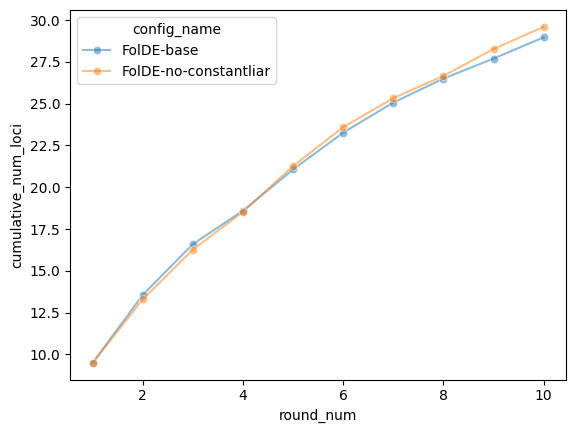

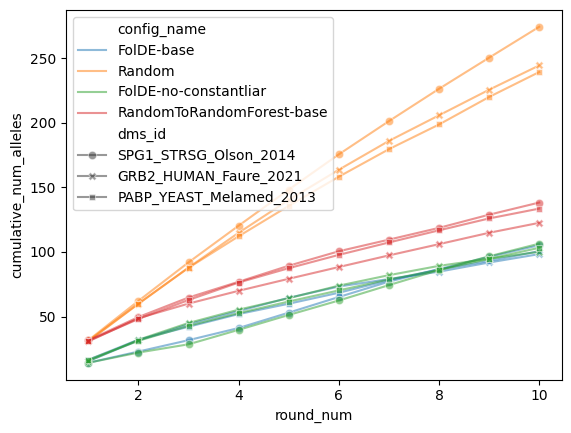

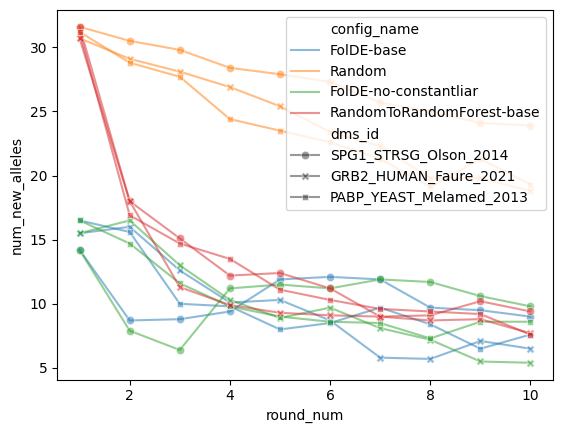

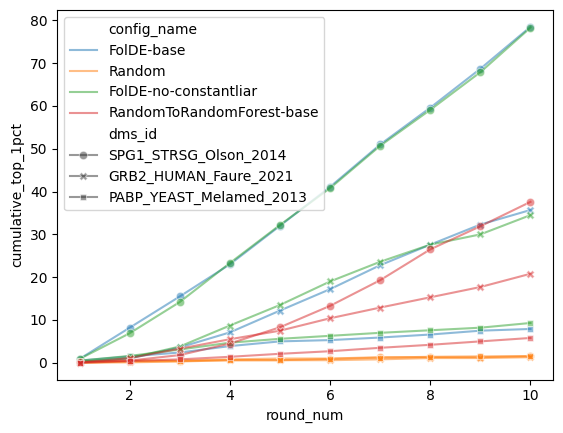

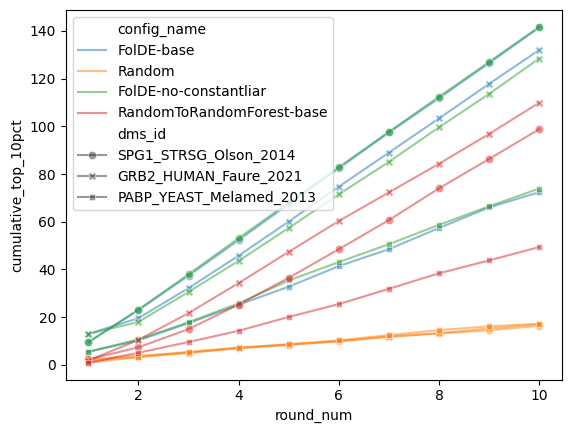

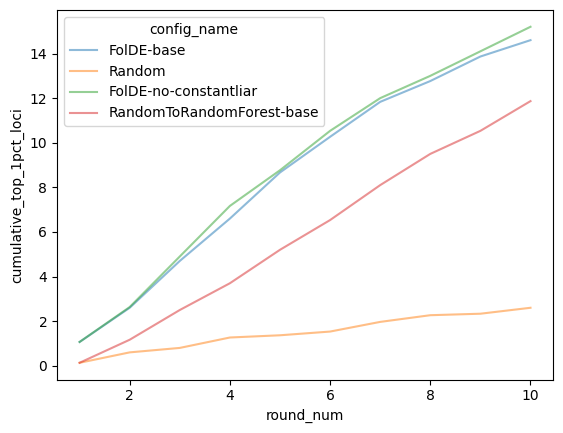

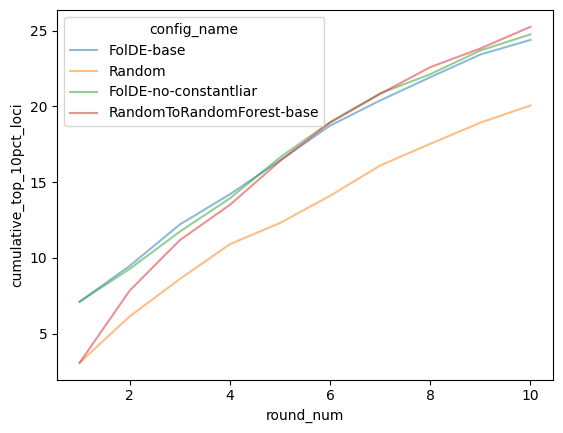

In [134]:
CONFIGS_TO_PLOT = ['FolDE-base', 'Random', 'RandomToRandomForest-base', 'FolDE-no-constantliar']

cumulative_hit_df_subset = multi_cumulative_hit_df[multi_cumulative_hit_df.config_name.isin(CONFIGS_TO_PLOT)]
# cumulative_hit_df_subset = singles_cumulative_hit_df[singles_cumulative_hit_df.config_name.isin(CONFIGS_TO_PLOT)]

sns.lineplot(
    data=cumulative_hit_df_subset[cumulative_hit_df_subset.config_name.isin(['FolDE-base', 'FolDE-no-constantliar'])],
    x='round_num',
    y='cumulative_num_loci',
    hue='config_name',
    legend='full',
    marker='o',
    dashes=False,
    alpha=0.5,
    errorbar=None,
)
plt.figure()
sns.lineplot(
    data=cumulative_hit_df_subset,
    x='round_num',
    y='cumulative_num_alleles',
    hue='config_name',
    style='dms_id',
    legend='full',
    markers=True,
    dashes=False,
    alpha=0.5,
    errorbar=None,
)
plt.figure()
sns.lineplot(
    data=cumulative_hit_df_subset,
    x='round_num',
    y='num_new_alleles',
    hue='config_name',
    style='dms_id',
    legend='full',
    markers=True,
    dashes=False,
    alpha=0.5,
    errorbar=None,
)
plt.figure()
sns.lineplot(
    data=cumulative_hit_df_subset,
    x='round_num',
    y='cumulative_top_1pct',
    hue='config_name',
    style='dms_id',
    legend='full',
    markers=True,
    dashes=False,
    alpha=0.5,
    errorbar=None,
)
plt.figure()
sns.lineplot(
    data=cumulative_hit_df_subset,
    x='round_num',
    y='cumulative_top_10pct',
    hue='config_name',
    style='dms_id',
    legend='full',
    markers=True,
    dashes=False,
    alpha=0.5,
    errorbar=None,
)
plt.figure()
sns.lineplot(
    data=cumulative_hit_df_subset,
    x='round_num',
    y='cumulative_top_1pct_loci',
    hue='config_name',
    legend='full',
    markers=True,
    dashes=False,
    alpha=0.5,
    errorbar=None,
)
plt.figure()
sns.lineplot(
    data=cumulative_hit_df_subset,
    x='round_num',
    y='cumulative_top_10pct_loci',
    hue='config_name',
    legend='full',
    markers=True,
    dashes=False,
    alpha=0.5,
    errorbar=None,
)

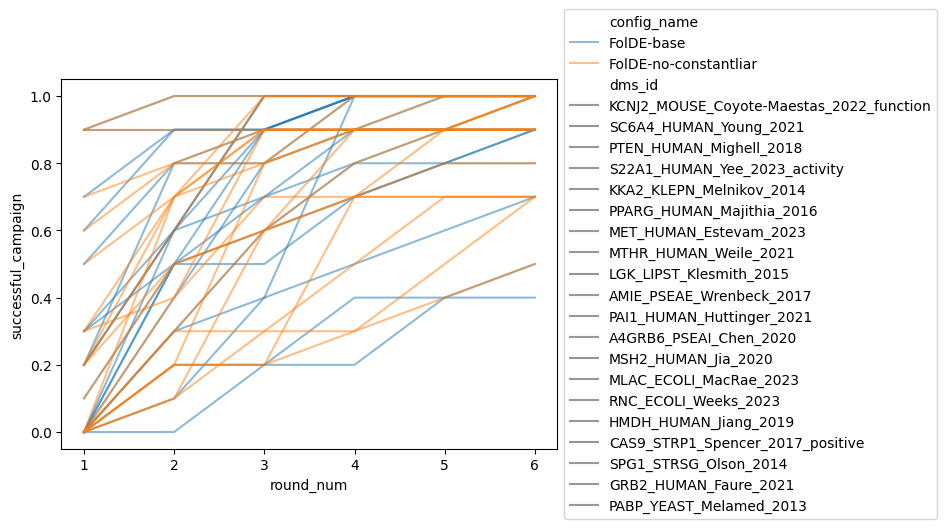

In [135]:
stats_df = pd.concat([singles_cumulative_hit_df, multi_cumulative_hit_df])  #cl_scan_cumulative_hit_df 

stats_df = stats_df[stats_df.round_num <= 6]

stats_df['successful_campaign'] = stats_df.cumulative_top_1pct > 0
ax = sns.lineplot(
    data=stats_df[stats_df.config_name.isin([
        # 'Random',
        # 'RandomToRandomForest-base',
        'FolDE-no-constantliar',
        # 'FolDE-no-zeroShot',
        'FolDE-base',
    ])],
    x='round_num',
    y='successful_campaign',
    hue='config_name',
    style='dms_id',
    legend='full',
    # markers=True,
    dashes=False,
    errorbar=None,
    alpha=0.5
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
pivoted = stats_df.groupby(['dms_id', 'round_num', 'config_name']).successful_campaign.mean().reset_index().pivot(index=['round_num', 'dms_id'], columns='config_name', values='successful_campaign')

In [136]:
multi_round_metrics_df.config_name.value_counts()

config_name
FolDE-clS1                                  300
FolDE-no-zeroShot                           300
FolDE-no-ensemble                           300
FolDE-base                                  300
Random                                      300
FolDE-no-MLP                                300
FolDE-clS6                                  300
RandomToRandomForest-300m-embeddings        300
FolDE-no-constantliar                       300
FolDE-no-BTLoss                             300
FolDE-clS3                                  300
FolDE-no-naturalnessTraining                300
FolDE-no-naturalnessTraining-or-ensemble    300
RandomToRandomForest-base                   300
Name: count, dtype: int64

In [137]:
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, ttest_rel


for metric in ['has_found_top_1pct', 'cumulative_10pct_hits']:
    for config in ['RandomToRandomForest-base', 'FolDE-base']:
        subset = multi_round_metrics_df[
            (multi_round_metrics_df.round_num == 3) &
            (multi_round_metrics_df.config_name == config)
        ][['dms_id', 'config_name', 'has_found_top_1pct', 'cumulative_10pct_hits']]
        print(f'{metric:21s} {config:28s}: {subset[metric].mean()}')


EPSILON = 1e-5
FOLDE_METHOD = 'FolDE-base' # 'FolDE-no-constantliar'
BASELINE = 'RandomToRandomForest-base'

def get_stats(local_hit_df, metric) -> [float, float, float, float, float, pd.DataFrame, pd.DataFrame]:
    """Returns (count, pvalue, min, median, max, single_endpoint_metrics_df, pivoted_enrichment_df)."""

    if metric == 'has_found_top_1pct':
        ################
        # cumulative_top_1pct / "successful campaign"
        ################
        single_endpoint_metrics_df = local_hit_df[local_hit_df.round_num == 3].copy()
        single_endpoint_metrics_df = single_endpoint_metrics_df.groupby(['dms_id', 'config_name']).agg({'has_found_top_1pct': 'mean', 'cumulative_10pct_hits': 'mean'})  # 'sim_num', 
        single_endpoint_metrics_df['metric'] = single_endpoint_metrics_df.has_found_top_1pct
        pivoted_enrichment_df = single_endpoint_metrics_df.reset_index().pivot(index=['dms_id'], columns='config_name', values='metric').reset_index()  # , 'sim_num'
        # pivoted_enrichment_df['theta'] = pivoted_enrichment_df[FOLDE_METHOD] - pivoted_enrichment_df[BASELINE]
        # metric_difference_vector = pivoted_enrichment_df['theta']
        pivoted_enrichment_df['theta'] = np.log10(pivoted_enrichment_df[FOLDE_METHOD]) - np.log10(pivoted_enrichment_df[BASELINE])
        metric_difference_vector = 10**(pivoted_enrichment_df['theta'])


    elif metric == 'cumulative_10pct_hits':
        ################
        # new_top_10pct
        ################
        single_endpoint_metrics_df = local_hit_df[local_hit_df.round_num <= 3].copy()
        single_endpoint_metrics_df = single_endpoint_metrics_df.groupby(['dms_id', 'config_name']).agg({'cumulative_10pct_hits': 'mean', 'new_10pct_hits': 'mean'})
        single_endpoint_metrics_df['metric'] = single_endpoint_metrics_df.new_10pct_hits
        pivoted_enrichment_df = single_endpoint_metrics_df.reset_index().pivot(index=['dms_id'], columns='config_name', values='metric').reset_index()  # , 'sim_num'
        pivoted_enrichment_df['theta'] = np.log10(pivoted_enrichment_df[FOLDE_METHOD]) - np.log10(pivoted_enrichment_df[BASELINE])
        metric_difference_vector = 10**(pivoted_enrichment_df['theta'])
    
    else:
        raise ValueError(f'Unknown metric: {metric}')

    median_x = float(np.median(metric_difference_vector))
    low_x = float(np.min(metric_difference_vector))
    high_x = float(np.max(metric_difference_vector))

    # One-sided Wilcoxon signed-rank test (median-based test)
    wilc = wilcoxon(pivoted_enrichment_df['theta'], alternative='greater')  # FolDE > RF
    p_wilc = wilc.pvalue

    return metric_difference_vector.shape[0], p_wilc, low_x, median_x, high_x, single_endpoint_metrics_df, pivoted_enrichment_df

# Median ×-improvement
for metric in ['has_found_top_1pct', 'cumulative_10pct_hits']:
    singles_stats = get_stats(singles_round_metrics_df, metric=metric)
    multis_stats = get_stats(multi_round_metrics_df, metric=metric)
    full_stats = get_stats(pd.concat([singles_round_metrics_df, multi_round_metrics_df]), metric=metric)

    def print_stats(name, stats):
        print(f'  {name} with {stats[0]} targets: p_wilc: {stats[1]} (min: {stats[2]:.3f}, median: {stats[3]:.3f}, max: {stats[4]:.3f}, higher in {(stats[-1].theta > 0.0).sum()}/{stats[-1].shape[0]})')

    print(f'\nProbability that {metric} is not higher for {FOLDE_METHOD} than {BASELINE}:')
    print_stats('Singles Benchmark', singles_stats)
    print_stats('Multis Benchmark', multis_stats)
    print_stats('Full Benchmark', full_stats)


has_found_top_1pct    RandomToRandomForest-base   : 0.6666666666666666
has_found_top_1pct    FolDE-base                  : 0.9666666666666667
cumulative_10pct_hits RandomToRandomForest-base   : 15.433333333333334
cumulative_10pct_hits FolDE-base                  : 29.033333333333335

Probability that has_found_top_1pct is not higher for FolDE-base than RandomToRandomForest-base:
  Singles Benchmark with 17 targets: p_wilc: 0.11083416753264685 (min: 0.250, median: 1.500, max: 3.000, higher in 11/17)
  Multis Benchmark with 3 targets: p_wilc: 0.125 (min: 1.111, median: 1.286, max: 2.500, higher in 3/3)
  Full Benchmark with 20 targets: p_wilc: 0.04889141891293059 (min: 0.250, median: 1.450, max: 3.000, higher in 14/20)

Probability that cumulative_10pct_hits is not higher for FolDE-base than RandomToRandomForest-base:
  Singles Benchmark with 17 targets: p_wilc: 0.03191375732421875 (min: 0.617, median: 1.134, max: 2.141, higher in 13/17)
  Multis Benchmark with 3 targets: p_wilc: 0.125 (

In [138]:
full_stats = get_stats(pd.concat([singles_round_metrics_df, multi_round_metrics_df]), metric='has_found_top_1pct')
full_stats[-1][FOLDE_METHOD].mean()


0.7150000000000001

# Main Fig3 Plot

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_52475/3090553096.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_div.set_xticklabels(stats.index)
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_52475/3090553096.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_enr.set_xticklabels(stats.index)
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_52475/3090553096.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_div.set_xticklabels(stats.index)
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_52475/3090553096.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_enr.set_xticklabels(stats.index)
/var

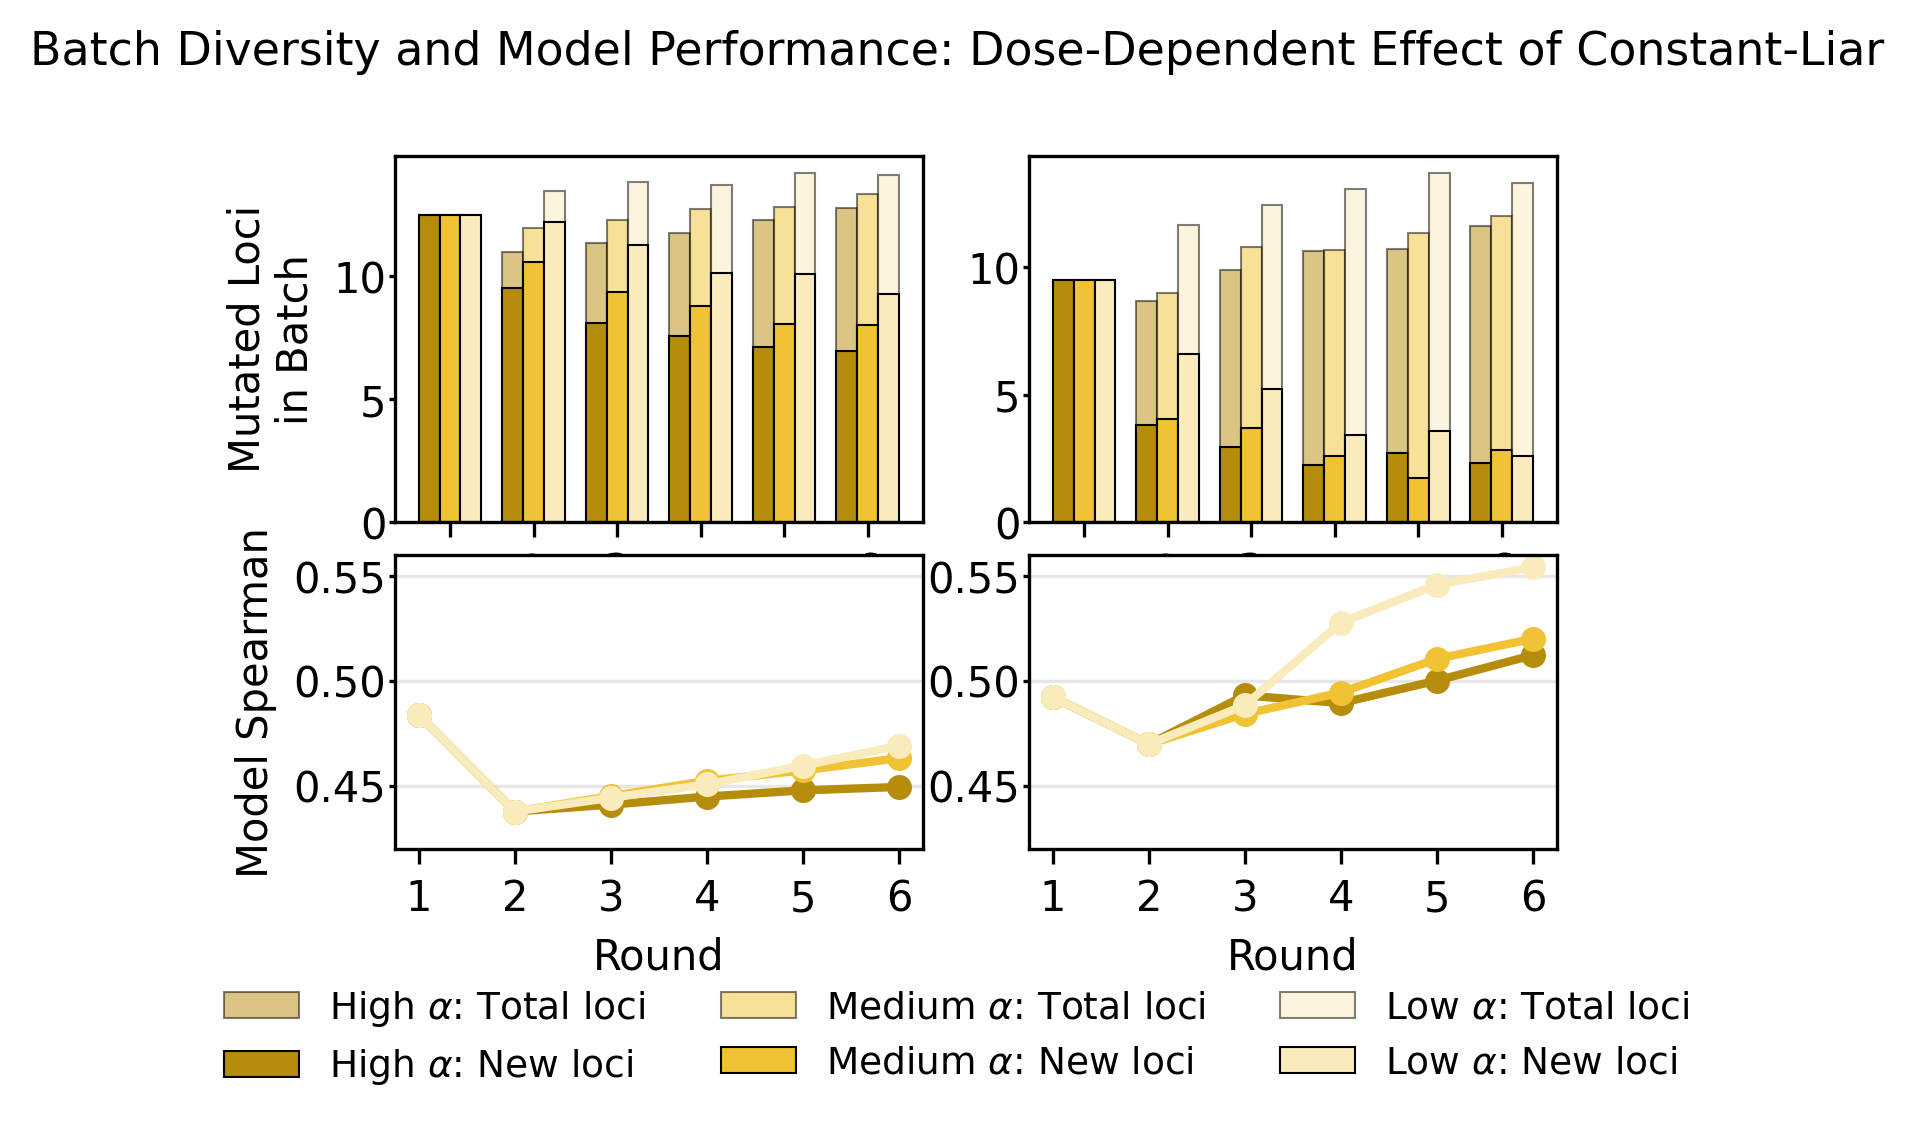

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create single gold color palette with gradient from light to dark
# gold_palette = sns.light_palette('#F1C233', n_colors=4)
# Cubehelix starting in gold/yellow range, rotating through warmer tones
# gold_palette = sns.cubehelix_palette(n_colors=5, start=1.2857142857142856, rot=-0.3, 
#                                       light=0.85, dark=0.3, reverse=False)
import matplotlib.colors as mcolors
import colorsys
import numpy as np

def create_lightness_palette(hex_color, n_colors=5):
    assert n_colors == 3
    rgb = mcolors.hex2color(hex_color)
    h, l, s = colorsys.rgb_to_hls(*rgb)

    FACTOR = 1.5
    
    # Create palette by varying lightness only
    lightness_values = [l / FACTOR, l, l * FACTOR]
    colors = [colorsys.hls_to_rgb(h, l_val, s) for l_val in lightness_values]
    return colors

gold_palette = create_lightness_palette('#F1C233', n_colors=3)

METHODS = [
    ('FolDE-no-constantliar', 'High $\\alpha$', gold_palette[0]),  # Darkest gold
    ('FolDE-clS6', 'Medium $\\alpha$', gold_palette[1]),           # Medium gold
    ('FolDE-clS1', 'Low $\\alpha$', gold_palette[2]),              # Light gold
]
BOTTOM_METRIC = 'held_out_activity_spearman'
MAX_ROUNDS = 6

def prepare_data(df, config_name, columns):
    """Helper function to prepare data for plotting"""
    subset = df[df.config_name == config_name].melt(
        id_vars=['dms_id', 'config_name', 'round_num', 'sim_num'],
        value_vars=columns,
        var_name='variable', 
        value_name='value'
    )
    stats = subset.groupby(['round_num', 'variable']).value.agg(['mean', 'sem']).unstack().fillna(0)
    return stats

def plot_diversity_and_enrichment(ax_div, ax_enr, div_df, metrics_df, title, 
                                  columns=['num_loci_this_round', 'num_new_loci']):
    """Plot diversity metrics and enrichment for one benchmark"""
    # Filter to first 6 rounds
    div_subset = div_df[div_df.round_num <= MAX_ROUNDS]
    metrics_subset = metrics_df[metrics_df.round_num <= MAX_ROUNDS]

    for method_idx, (method, method_label, color) in enumerate(METHODS):
        stats = prepare_data(div_subset, method, columns)
        rounds = np.arange(len(stats.index))
        bar_width = 0.25  # Narrower bars to fit 3 groups
        for i, col in enumerate(columns):
            means = stats['mean'][col]
            # First column (num_loci_this_round) is the "behind bar" - gets hatch
            # Second column (num_new_loci) is the "front bar" - solid
            label = 'Total loci' if i == 0 else 'New loci'
            extra_args = {}
            if i == 0:
                extra_args = {
                    # 'hatch': '///',
                    'alpha': 0.5,
                    # 'edgecolor': 'black',
                    # 'linewidth': 0.5
                }
            ax_div.bar(
                rounds + (method_idx - 1) * bar_width, means, bar_width,
                label=f'{method_label}: {label}', 
                color=color,
                edgecolor="black", 
                linewidth=0.5,
                **extra_args
            )
        ax_div.set_xticklabels(stats.index)
        ax_div.set_xticks(rounds)
        ax_enr.set_xticklabels(stats.index)
        ax_enr.set_xticks(rounds)
    
    # Format diversity axis
    ax_div.set_xlabel("")  # Remove x-label from top plot
    ax_div.set_ylabel("Mutated Loci\nin Batch")
    ax_div.set_title(title)
    ax_div.set_ylim(0, ax_div.get_ylim()[1])
    
    # Plot enrichment lines
    for method, method_label, color in METHODS:
        enr_subset = metrics_subset[metrics_subset.config_name == method].groupby('round_num')[BOTTOM_METRIC].mean()
        ax_enr.plot(rounds, enr_subset.values,
                    color=color, linestyle='-', linewidth=2,
                    marker='o', markersize=5, label=method_label)
    
    # Format enrichment axis
    ax_enr.set_xlabel("Round")
    ax_enr.set_ylabel("Model Spearman")
    ax_enr.grid(True, alpha=0.3, axis='y')
    # Set consistent y-limits to prevent label overlap
    ax_enr.set_ylim(0.42, 0.56)
    # Move tick labels closer to the plot
    ax_enr.tick_params(axis='y', pad=2)

# Create figure with 2x2 grid
fig = plt.figure(figsize=(5, 3), dpi=300)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8], hspace=0.1)

# Create axes
ax1_div = fig.add_subplot(gs[0, 0])
ax1_enr = fig.add_subplot(gs[1, 0])
ax2_div = fig.add_subplot(gs[0, 1])
ax2_enr = fig.add_subplot(gs[1, 1])

# Plot singles benchmark
plot_diversity_and_enrichment(
    ax1_div, ax1_enr, 
    singles_cumulative_hit_df, 
    singles_round_metrics_df,
    "",
)

# Plot multi benchmark
plot_diversity_and_enrichment(
    ax2_div, ax2_enr,
    multi_cumulative_hit_df,
    multi_round_metrics_df,
    ""
)
ax2_div.set_ylabel('')
ax2_enr.set_ylabel('')

# Move tick labels closer to the plot for bottom-right as well
for ax in [ax1_div, ax1_enr, ax2_div, ax2_enr]:
    ax.tick_params(axis='y', pad=0.5, length=1.5)

# Add shared legend at the bottom for diversity metrics
handles, labels = ax1_div.get_legend_handles_labels()
# Only show unique labels in legend
unique_labels = []
unique_handles = []
for h, l in zip(handles, labels):
    if any(x in l for x in ['Total loci', 'New loci']):
        # Simplify legend for diversity bars
        if 'High $\\alpha$' in l and l not in unique_labels:
            unique_labels.append(l)
            unique_handles.append(h)
        elif 'Medium $\\alpha$' in l and l not in unique_labels:
            unique_labels.append(l)
            unique_handles.append(h)
        elif 'Low $\\alpha$' in l and l not in unique_labels:
            unique_labels.append(l)
            unique_handles.append(h)

fig.legend(unique_handles, unique_labels,
          loc='center', 
          bbox_to_anchor=(0.5, -0.1),
          ncol=3,
          frameon=False,
          fontsize=9)

plt.suptitle("Batch Diversity and Model Performance: Dose-Dependent Effect of Constant-Liar", 
             y=1.02, fontsize=11)
plt.tight_layout()

plt.savefig('notebooks/jacob/paperplots/fig3_constantliar_num_loci_metrics.svg', bbox_inches='tight', transparent=True)
plt.show()

In [140]:
gold_palette

[(0.7143730886850153, 0.5497871319781735, 0.04902560412544221),
 (0.9450980392156864, 0.7607843137254903, 0.19999999999999984),
 (0.981867242309768, 0.9209929843497031, 0.7357798165137613)]

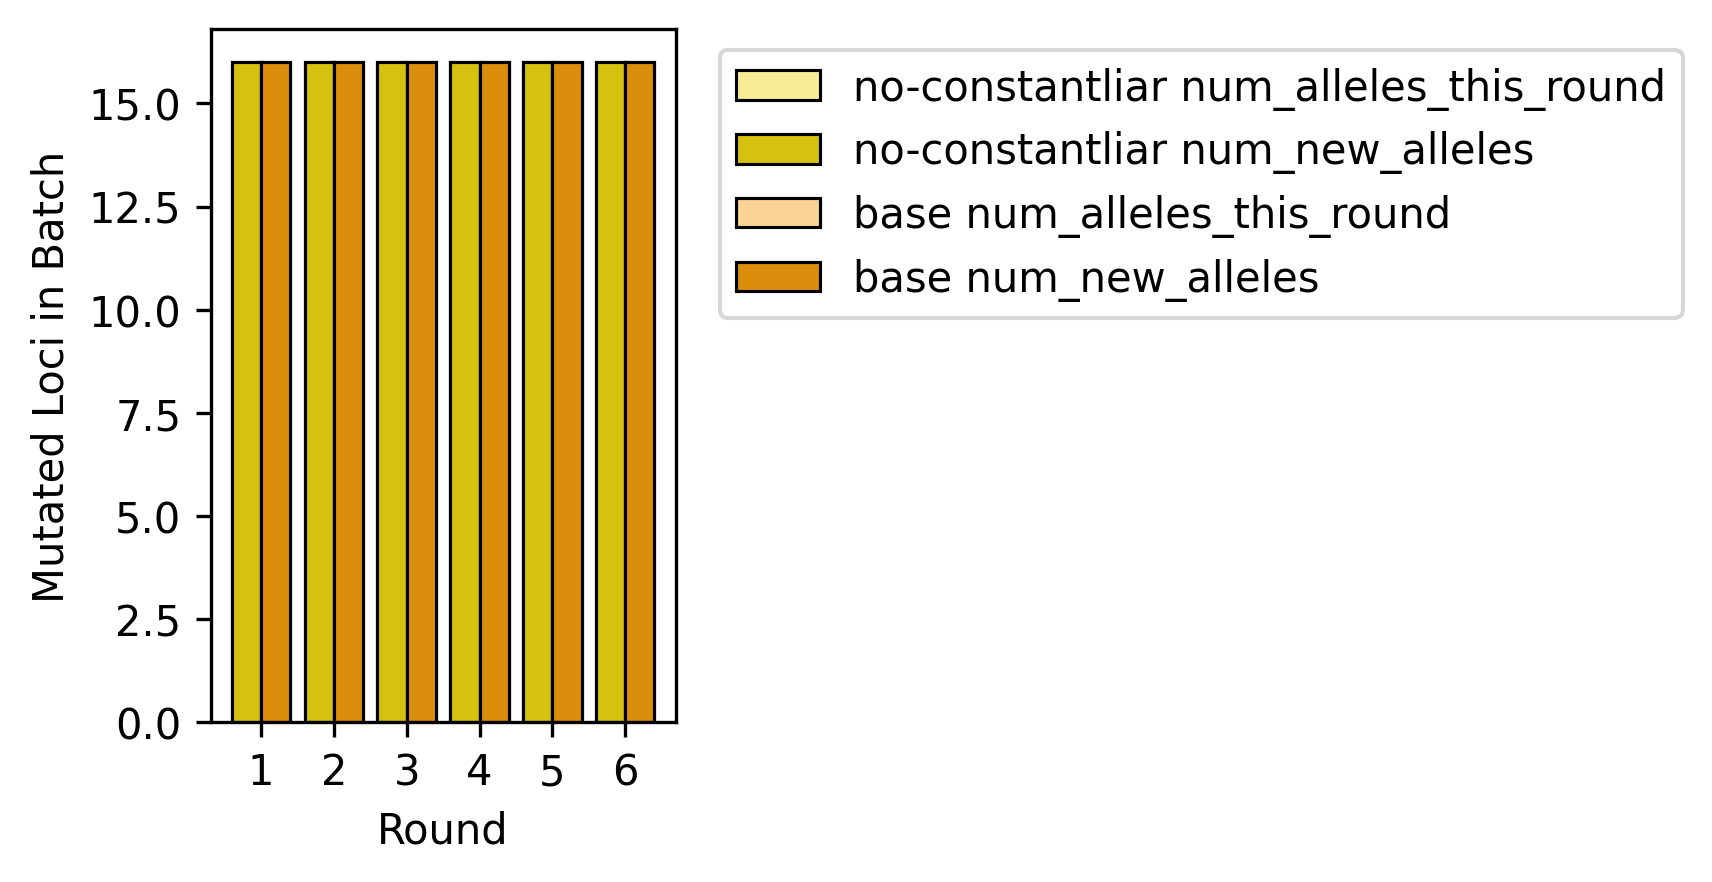

In [142]:
import matplotlib.pyplot as plt
import numpy as np

COLUMNS = ['num_alleles_this_round','num_new_alleles']

cumulative_hit_subset_df = singles_cumulative_hit_df[singles_cumulative_hit_df.round_num <= 6]

# Subset and melt for each config
df_no_const = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-no-constantliar'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

df_base = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-base'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

# Compute mean + sem
df_no_const_stats = df_no_const.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)
df_base_stats     = df_base.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)

rounds = np.arange(len(df_no_const_stats.index))  # x positions
bar_width = 0.4
bar_gap = 0.00

colors_no_const = ["#f7ed97", "#d5c210"]
colors_base     = ["#f9d494", "#da8e0b"]

fig, ax = plt.subplots(figsize=(2, 3), dpi=300)

# Left group (no-constantliar)
for col, color in zip(COLUMNS, colors_no_const):
    means = df_no_const_stats['mean'][col]
    sems  = df_no_const_stats['sem'][col]
    ax.bar(rounds - bar_width/2 - bar_gap/2, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'no-constantliar {col}', color=color,
           edgecolor="black", linewidth=0.75)

# Right group (base)
for col, color in zip(COLUMNS, colors_base):
    means = df_base_stats['mean'][col]
    sems  = df_base_stats['sem'][col]
    ax.bar(rounds + bar_width/2 + bar_gap/2, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'base {col}', color=color,
           edgecolor="black", linewidth=0.75)

ax.set_xticks(rounds)
ax.set_xticklabels(df_no_const_stats.index)
ax.set_xlabel("Round")
ax.set_ylabel("Mutated Loci in Batch")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

KeyError: 'mean'

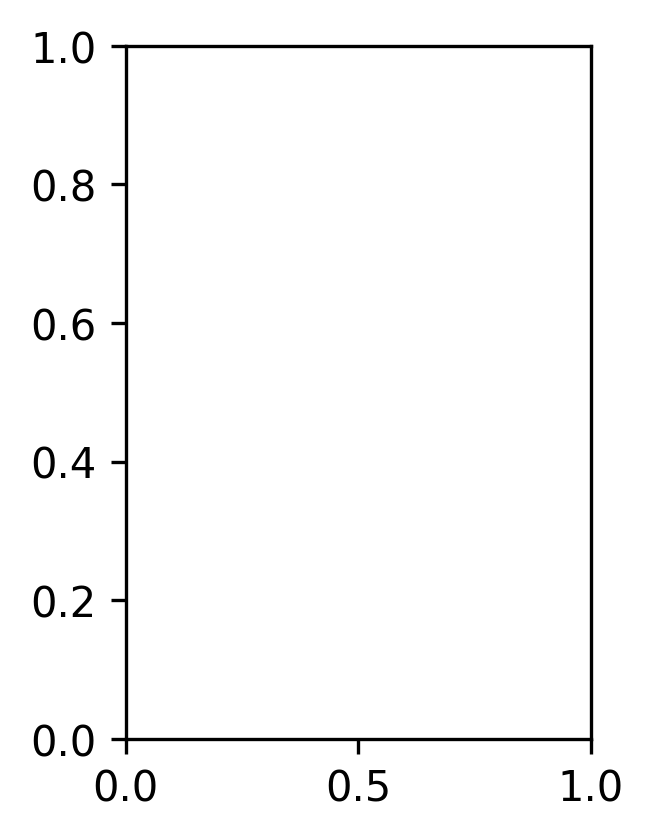

In [149]:
import matplotlib.pyplot as plt
import numpy as np

COLUMNS = ['num_loci_this_round','num_new_loci']

cumulative_hit_subset_df = multi_cumulative_hit_df[multi_cumulative_hit_df.round_num <= 6]

# Subset and melt for each config
df_random = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-no-constantliar-ucb'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

# Subset and melt for each config
df_no_const = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-no-constantliar'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

df_base = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-base'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

# Compute mean + sem
df_random_stats = df_random.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)
df_no_const_stats = df_no_const.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)
df_base_stats     = df_base.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)

rounds = np.arange(len(df_no_const_stats.index))  # x positions
bar_width = 0.28
bar_gap = 0.00

colors_random = ['#dddddd', '#aaaaaa']
colors_no_const = ["#f7ed97", "#d5c210"]
colors_base     = ["#f9d494", "#da8e0b"]

fig, ax = plt.subplots(figsize=(2, 3), dpi=300)

# Left group (no-constantliar)
for col, color in zip(COLUMNS, colors_random):
    means = df_random_stats['mean'][col]
    sems  = df_random_stats['sem'][col]
    ax.bar(rounds - bar_width - bar_gap/2, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'random {col}', color=color,
           edgecolor="black", linewidth=0.75)

for col, color in zip(COLUMNS, colors_no_const):
    means = df_no_const_stats['mean'][col]
    sems  = df_no_const_stats['sem'][col]
    ax.bar(rounds, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'no-constantliar {col}', color=color,
           edgecolor="black", linewidth=0.75)

# Right group (base)
for col, color in zip(COLUMNS, colors_base):
    means = df_base_stats['mean'][col]
    sems  = df_base_stats['sem'][col]
    ax.bar(rounds + bar_width + bar_gap/2, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'base {col}', color=color,
           edgecolor="black", linewidth=0.75)

ax.set_xticks(rounds)
ax.set_xticklabels(df_no_const_stats.index)
ax.set_xlabel("Round")
ax.set_ylabel("Mutated Loci in Batch")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# FolDE (no constant liar) vs UCB

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_62906/2327472245.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


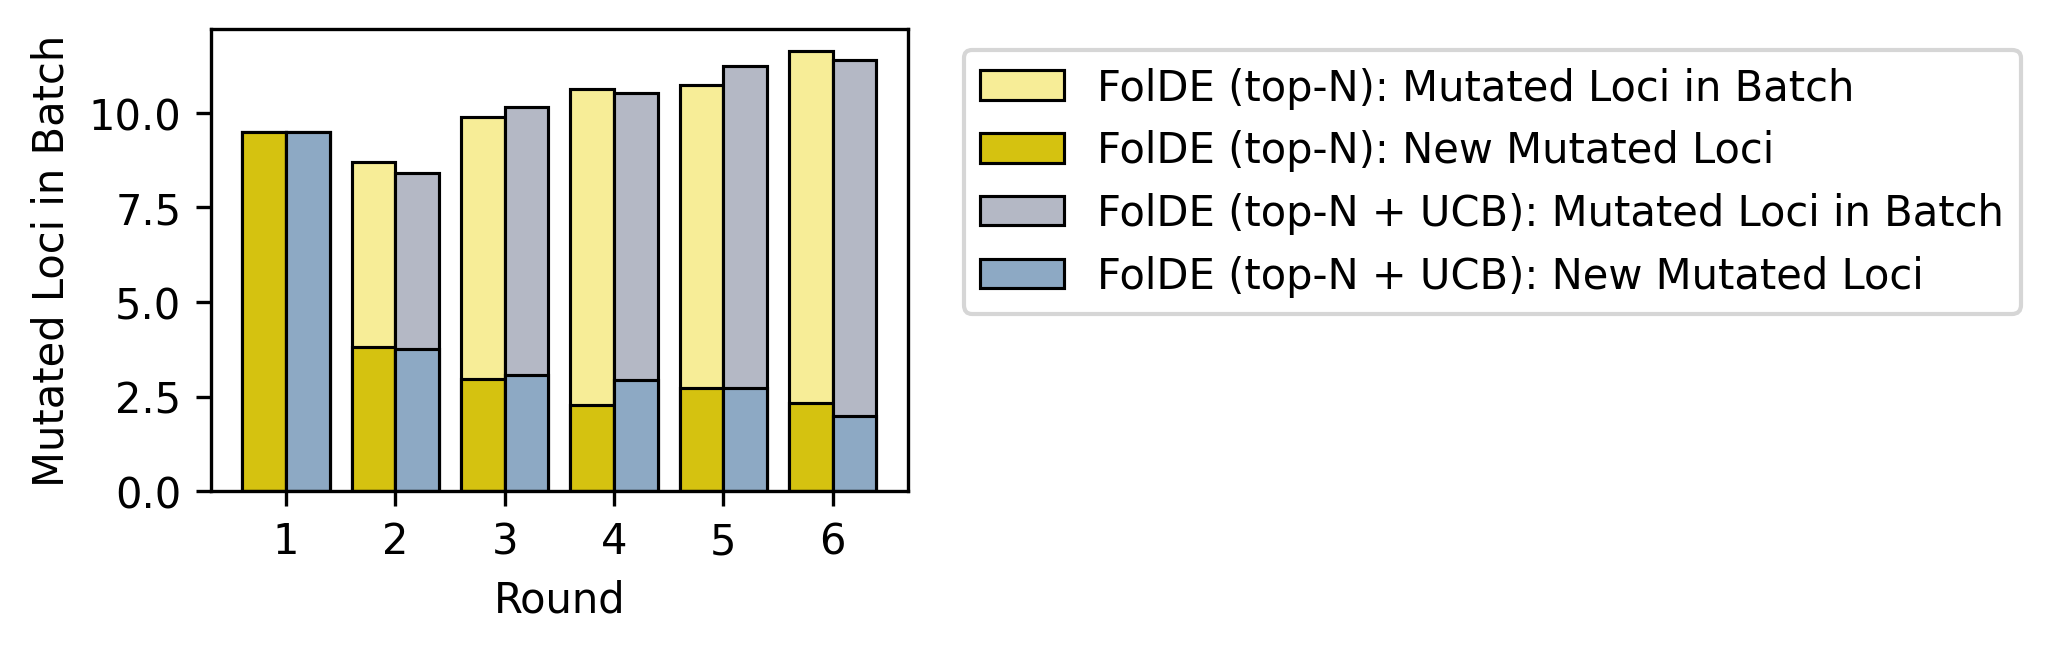

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

COLUMNS = ['num_loci_this_round','num_new_loci']
COLUMN_NAMES = ['Mutated Loci in Batch', 'New Mutated Loci']

cumulative_hit_subset_df = multi_cumulative_hit_df[multi_cumulative_hit_df.round_num <= 6]
# relevant_round_metrics_df = singles_round_metrics_df[singles_round_metrics_df.round_num <= 6]
multi_round_metrics_df['enrichment'] = multi_round_metrics_df.held_out_1pct_recall / 0.01 + multi_round_metrics_df.held_out_10pct_recall / 0.1
relevant_round_metrics_df = multi_round_metrics_df[multi_round_metrics_df.round_num <= 6]

# Subset and melt for each config
df_no_const = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-no-constantliar'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

df_ucb = cumulative_hit_subset_df[cumulative_hit_subset_df.config_name == 'FolDE-no-constantliar-ucb'].melt(
    id_vars=['dms_id','config_name','round_num','sim_num'],
    value_vars=COLUMNS,
    var_name='variable', value_name='value'
)

# Compute mean + sem
df_no_const_stats = df_no_const.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)
df_ucb_stats     = df_ucb.groupby(['round_num','variable']).value.agg(['mean','sem']).unstack().fillna(0)

rounds = np.arange(len(df_no_const_stats.index))  # x positions
bar_width = 0.4
bar_gap = 0.00

colors_no_const = ["#f7ed97", "#d5c210"]
colors_ucb     = ["#B4B8C5", "#8DA9C4"]

fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
# fig, (ax, ax2) = plt.subplots(1, 2, figsize=(6, 2), dpi=300)

# Left group (no-constantliar)
for col, color, col_name in zip(COLUMNS, colors_no_const, COLUMN_NAMES):
    means = df_no_const_stats['mean'][col]
    sems  = df_no_const_stats['sem'][col]
    ax.bar(rounds - bar_width/2 - bar_gap/2, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'FolDE (top-N): {col_name}', color=color,
           edgecolor="black", linewidth=0.75)

# Right group (base)
for col, color, col_name in zip(COLUMNS, colors_ucb, COLUMN_NAMES):
    means = df_ucb_stats['mean'][col]
    sems  = df_ucb_stats['sem'][col]
    ax.bar(rounds + bar_width/2 + bar_gap/2, means, bar_width,
        #    yerr=sems, capsize=0,
           label=f'FolDE (top-N + UCB): {col_name}', color=color,
           edgecolor="black", linewidth=0.75)

ax.set_xticks(rounds)
ax.set_xticklabels(df_no_const_stats.index)
ax.set_xlabel("Round")
ax.set_ylabel("Mutated Loci in Batch")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot enrichment lines
# sns.lineplot(data=relevant_round_metrics_df[relevant_round_metrics_df.config_name == 'FolDE-no-constantliar'],
#              x='round_num', y='enrichment', ax=ax2,
#              color=colors_no_const[1], linestyle='--', linewidth=1.5,
#              marker='o', markersize=4, label='FolDE-no-constantliar')
# sns.lineplot(data=relevant_round_metrics_df[relevant_round_metrics_df.config_name == 'FolDE-no-constantliar-ucb'],
#              x='round_num', y='enrichment', ax=ax2,
#              color=colors_ucb[1], linestyle='--', linewidth=1.5,
#              marker='o', markersize=4, label='FolDE-no-constantliar-ucb')
# sns.lineplot(data=relevant_round_metrics_df[relevant_round_metrics_df.config_name == 'FolDE-base'],
#              x='round_num', y='enrichment', ax=ax2,
#              color='red', linestyle='--', linewidth=1.5,
#              marker='o', markersize=4, label='FolDE-base')
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# # ax2.plot(rounds, df_ucb_stats['mean']['enrichment'],
# #          color=colors_ucb[1], linestyle='--', linewidth=1.5, 
# #          marker='o', markersize=4)

# ax.legend_.remove()
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ax2.set_ylabel('Enrichment')

# Adjust layout to prevent label overlap
plt.tight_layout()

plt.show()

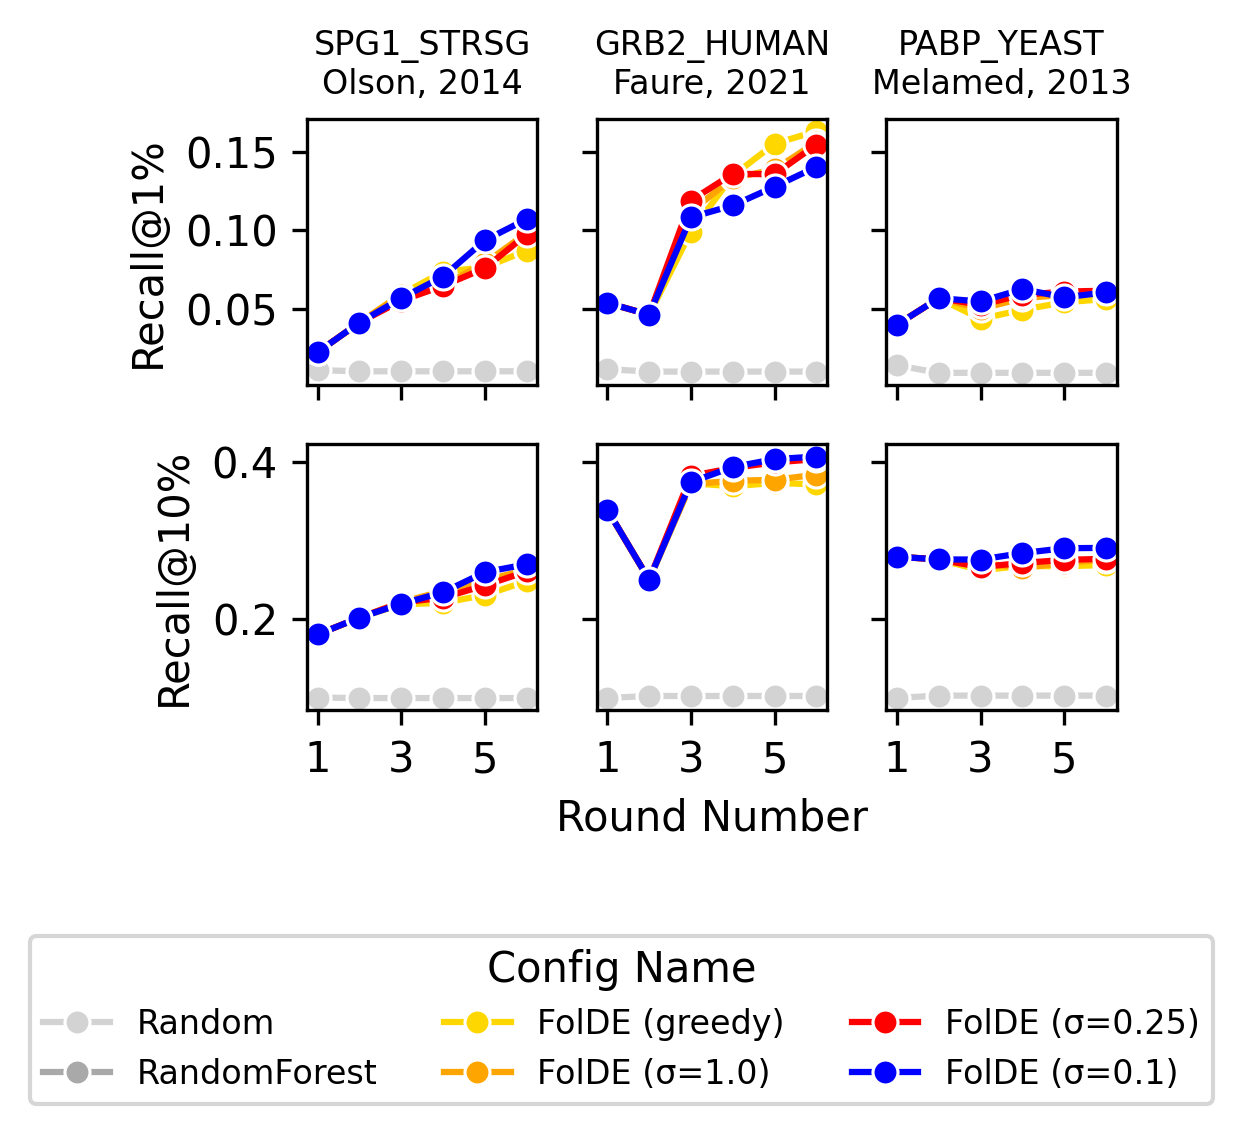

In [ ]:
import re

# Get unique dms_ids from the data
dms_ids = multimutant_dms_ids  # round_metrics_df.dms_id.unique()

CONFIG_RENAME_DICT = {
    'Random': 'Random',
    'RandomToRandomForest': 'RandomForest',
    'FolDE-no-constantliar': 'FolDE (greedy)',
    'FolDE-clS1': 'FolDE (σ=1.0)',
    'FolDE-base': 'FolDE (σ=0.25)',
    'FolDE-clS01': 'FolDE (σ=0.1)',
}
CONFIGS = CONFIG_RENAME_DICT.keys()

PALETTE = {
    'Random': 'lightgrey',
    'RandomForest': 'darkgrey',
    'FolDE (greedy)': 'gold',
    'FolDE (σ=1.0)': 'orange',
    'FolDE (σ=0.25)': 'red',
    'FolDE (σ=0.1)': 'blue',
}

# Create subplot grid: 2 rows, len(dms_ids) columns
fig, axes = plt.subplots(2, len(dms_ids), figsize=(len(dms_ids) * 1.2, 3), sharex=True, sharey='row', dpi=300)

plot_df = multi_round_metrics_df[multi_round_metrics_df.config_name.isin(CONFIG_RENAME_DICT.keys())].copy()
plot_df['Workflow'] = plot_df.config_name.apply(lambda x: CONFIG_RENAME_DICT[x])
plot_df['Protein Target'] = plot_df.dms_id
plot_df = plot_df[plot_df.round_num <= 6]
# plot_df['workflow'] = plot_df.config_name.apply(lambda x: x.split('-')[0])
# plot_df['benchmark'] = plot_df.config_name.apply(lambda x: '-'.join(x.split('-')[1:]))

metrics = ['held_out_1pct_recall', 'held_out_10pct_recall']#, 'best_percentile_so_far']

for col_idx, dms_id in enumerate(dms_ids):
    dms_data = plot_df[plot_df.dms_id == dms_id]
    
    for row_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        if row_idx < 2:
            sns.lineplot(
                ax=ax,
                data=dms_data,
                y=metric,
                x='round_num',
                hue='Workflow',
                errorbar=None,
                marker='o',
                hue_order=CONFIG_RENAME_DICT.values(),
                palette=PALETTE
            )
        else:
            sns.barplot(
                ax=ax,
                data=multimutant_diversity_df[(multimutant_diversity_df.dms_id == dms_id) & (multimutant_diversity_df.config_name.isin(CONFIGS))],
                y='num_alleles_in_slate',
                x='round_num',
                hue='Workflow',
                errorbar=None,
                hue_order=CONFIG_RENAME_DICT.values(),
                palette=PALETTE
                # marker='o'
            )

        # if row_idx == 2:
        #     ax.set_ylim(0.99, 1)
        
        # Set titles
        if row_idx == 0:
            first_half = '_'.join(dms_id.split('_')[:2])
            second_half = ', '.join(dms_id.split('_')[2:])
            ax.set_title(f'{first_half}\n{second_half}', fontsize=8)
        
        # Set y-labels only for leftmost column
        if col_idx == 0:
            if metric == 'held_out_1pct_recall':
                ax.set_ylabel('Recall@1%')
            else:
                ax.set_ylabel('Recall@10%')
        else:
            ax.set_ylabel('')
        
        # Set x-label only for bottom row
        if row_idx == 1 and col_idx == 1:
            ax.set_xlabel('Round Number')
        else:
            ax.set_xlabel('')
        
        if row_idx == 1:
            ax.set_xticks([1, 3, 5])
        
        # Remove legends from individual subplots
        if ax.get_legend():
            ax.get_legend().remove()
        # ax.axvline(x=2, color='black', linestyle='--')

# Add a single legend for the entire figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Config Name', loc='center', bbox_to_anchor=(0.5, -0.15), ncol=len(CONFIGS)//2, fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/jacob/paperplots/fig3_constantliar_case_studies.svg', dpi=300)

## Now let's look at those slates

In [148]:
CONFIG_RENAME_DICT = {
    'Random': 'Random',
    'RandomToRandomForest': 'RandomForest',
    'FolDE-no-constantliar': 'FolDE (greedy)',
    'FolDE-clS1': 'FolDE (σ=1.0)',
    'FolDE-base': 'FolDE (σ=0.25)',
}

PALETTE = {
    'Random': 'lightgrey',
    'RandomForest': 'darkgrey',
    'FolDE (greedy)': 'gold',
    'FolDE (σ=1.0)': 'orange',
    'FolDE (σ=0.25)': 'red',
}

performance_df = multi_round_metrics_df[['dms_id', 'config_name', 'round_num', 'sim_num', 'held_out_1pct_recall', 'held_out_10pct_recall', 'best_percentile_so_far']]
performance_df = pd.merge(
    performance_df,
    multimutant_diversity_df.copy(),
    on=['dms_id', 'config_name', 'round_num', 'sim_num']
)
performance_df['normalized_num_loci_in_slate'] = performance_df.num_loci_in_slate / performance_df.num_loci_in_slate_random
performance_df = performance_df[performance_df.round_num == 2]
performance_df['Workflow'] = performance_df.config_name.apply(lambda x: CONFIG_RENAME_DICT.get(x, pd.NA))
performance_df = performance_df[performance_df.Workflow.notna()]
performance_df['Protein Target'] = performance_df.dms_id
performance_df = performance_df.drop(columns=['config_name', 'dms_id'])

fig, axes = plt.subplots(2, 1, figsize=(1.5, 3), dpi=300, gridspec_kw={'hspace': 0.29})
for row_idx, (ax, METRIC) in enumerate(zip(axes, ['held_out_1pct_recall', 'held_out_10pct_recall'])):

    plot_df = performance_df.groupby(['Protein Target', 'Workflow']).mean().reset_index()  # 'dms_id',
    # plot_df = plot_df.groupby('config_name')[[METRIC, 'num_loci_in_slate']].mean().reset_index()
    sns.scatterplot(
        ax=ax,
        data=plot_df,
        x=METRIC,
        y='num_loci_in_slate',
        hue='Workflow',
        style='Protein Target',
        palette=PALETTE,
        hue_order=CONFIG_RENAME_DICT.values()
    )
    if row_idx == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend().remove()
    # ax.set_xlim(0, 0.05)
    ax.tick_params(axis='x', length=2, pad=1)
    if METRIC == 'held_out_1pct_recall':
        ax.set_xlabel('Recall@1%', fontsize=8, labelpad=1)
        ax.set_xticks([0, 0.02, 0.04, 0.06])
        ax.set_xticklabels(['0%', '2%', '4%', '6%'], fontsize=8)
    elif METRIC == 'held_out_10pct_recall':
        ax.set_xlabel('Recall@10%', fontsize=8, labelpad=1)
        ax.set_xticks([0, 0.2, 0.4])
        ax.set_xticklabels(['0%', '20%', '40%'], fontsize=8)
    else:
        assert False
    ax.set_ylabel('')
plt.ylabel('Mutant Diversity\nNum. Loci in Slate')


fig, axes = plt.subplots(1, 3, figsize=(4, 1), dpi=300)
for col_idx, dms_id in enumerate(multimutant_dms_ids):
    ax = axes[col_idx]
    sns.scatterplot(
        ax=ax,
        data=performance_df[performance_df['Protein Target'] == dms_id],
        x=METRIC,
        y='num_loci_in_slate',
        hue='Workflow',
        palette=PALETTE,
        hue_order=CONFIG_RENAME_DICT.values()
    )
    if col_idx == 2:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend().remove()
    
    if col_idx == 0:
        ax.set_ylabel('Number of loci in slate')
    else:
        ax.set_ylabel('')

    if col_idx == 1:
        ax.set_xlabel('Recall 1%')
    else:
        ax.set_xlabel('')



fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=300)
plot_df = performance_df.groupby(['Protein Target', 'Workflow']).mean().reset_index()  # 'dms_id',
# plot_df = plot_df.groupby('config_name')[[METRIC, 'num_loci_in_slate']].mean().reset_index()
sns.scatterplot(
    ax=ax,
    data=plot_df,
    x='best_percentile_so_far',
    y='num_loci_in_slate',
    hue='Workflow',
    style='Protein Target',
    palette=PALETTE,
        hue_order=CONFIG_RENAME_DICT.values()
)
ax.legend(bbox_to_anchor=(1.6, 1), loc='upper left')

# ax.set_xlim(0, 0.05)
ax.tick_params(axis='x', length=2, pad=1)
ax.set_xlabel('Mutant Quality\n(Max Quantile in Slate)', fontsize=8, labelpad=1)
ax.set_ylabel('Mutant Diversity\nNum. Loci in Slate')


# First arrow: (0.96,20) -> (0.985, 7)
plt.annotate('', xy=(0.99, 7), xytext=(0.96, 20),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# First annotation at (0.96, 10) with bottom left anchor
plt.text(0.96, 7, "Greedy algorithms\nselect the same\nmutations repeatedly",
         ha='left', va='bottom', fontsize=6, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Second arrow: (0.996, 8) -> (0.996, 15)  
plt.annotate('', xy=(0.996, 15), xytext=(0.996, 8),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Second annotation at (0.998, 10) with bottom left anchor
plt.text(0.998, 11, "Reducing σ prevents\nmode collapse while\nmaintaining quality",
         ha='left', va='bottom', fontsize=6,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
         

NameError: name 'multimutant_diversity_df' is not defined

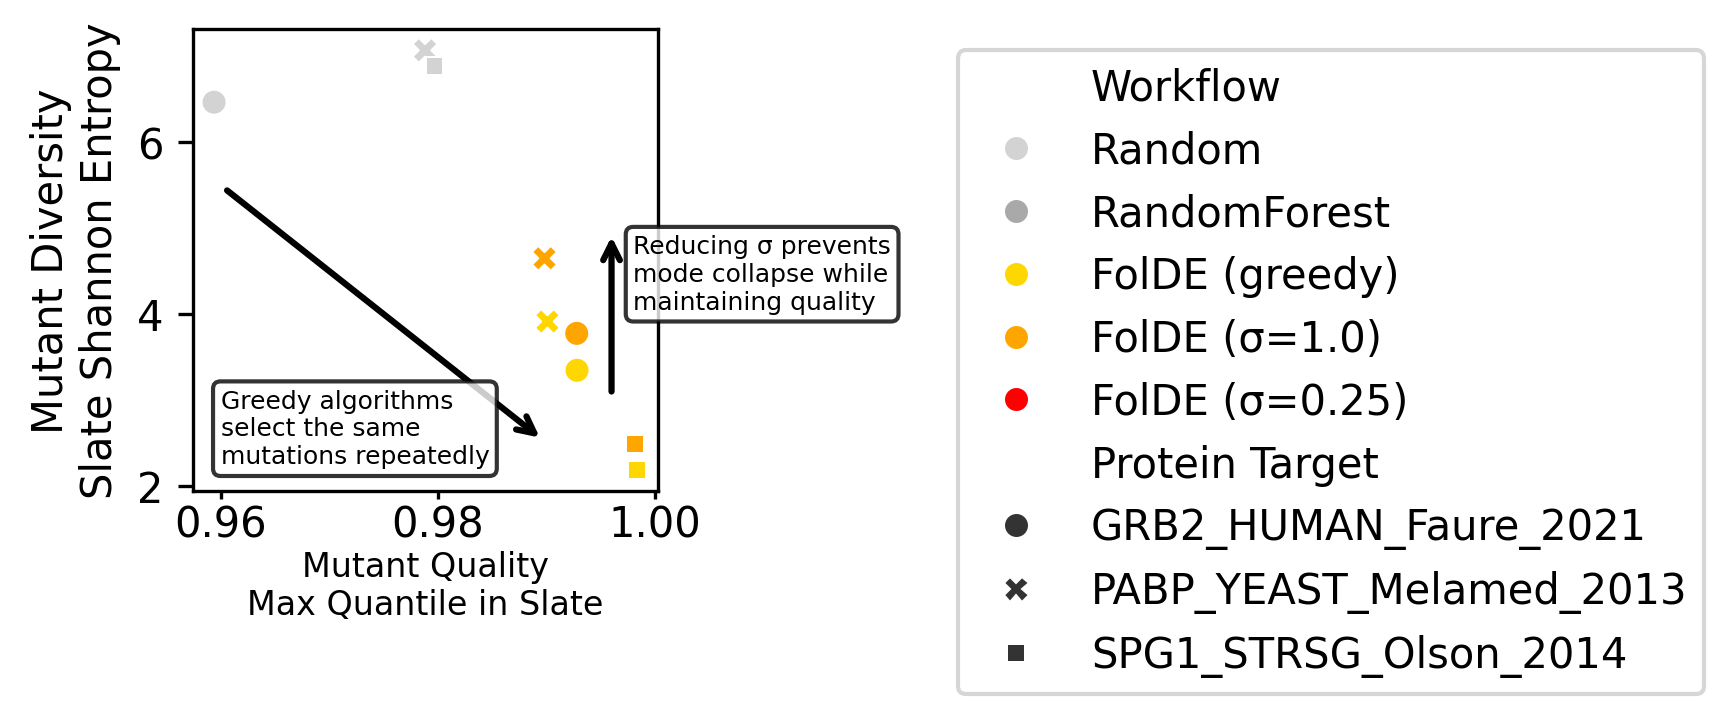

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=300)
plot_df = performance_df.groupby(['Protein Target', 'Workflow']).mean().reset_index()  # 'dms_id',
# plot_df = plot_df.groupby('config_name')[[METRIC, 'num_loci_in_slate']].mean().reset_index()
sns.scatterplot(
    ax=ax,
    data=plot_df,
    x='best_percentile_so_far',
    y='shannon_entropy',
    hue='Workflow',
    style='Protein Target',
    palette=PALETTE,
        hue_order=CONFIG_RENAME_DICT.values()
)
ax.legend(bbox_to_anchor=(1.6, 1), loc='upper left')

# ax.set_xlim(0, 0.05)
ax.tick_params(axis='x', length=2, pad=1)
ax.set_xlabel('Mutant Quality\nMax Quantile in Slate', fontsize=8, labelpad=1)
ax.set_ylabel('Mutant Diversity\nSlate Shannon Entropy')


# First arrow: (0.96,20) -> (0.985, 7)
plt.annotate('', xy=(0.99, 2.5), xytext=(0.96, 5.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# First annotation at (0.96, 10) with bottom left anchor
plt.text(0.96, 2.2, "Greedy algorithms\nselect the same\nmutations repeatedly",
         ha='left', va='bottom', fontsize=6, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Second arrow: (0.996, 8) -> (0.996, 15)  
plt.annotate('', xy=(0.996, 5), xytext=(0.996, 3),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Second annotation at (0.998, 10) with bottom left anchor
plt.text(0.998, 4, "Reducing σ prevents\nmode collapse while\nmaintaining quality",
         ha='left', va='bottom', fontsize=6,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.savefig('notebooks/jacob/paperplots/fig3_constantliar_diversity_v_quality.svg', dpi=300, bbox_inches='tight')

### Get a low and high diversity slate

We're looking at examples of PABP_YEAST_Melamed_2013 from the sims to explain what diversity looks like, and some runs are being reproduced in Foldy: https://foldy.lbl.gov/fold/8532/fewshot

In [ ]:
multimutant_diversity_df[
    (multimutant_diversity_df.config_name == 'Random') &
    (multimutant_diversity_df.dms_id == 'PABP_YEAST_Melamed_2013') &
    (multimutant_diversity_df.round_num == 2)
]
# mutant_df_multimutant[
#     (mutant_df_multimutant.config_name == 'FolDE-no-constantliar') &
#     (mutant_df_multimutant.dms_id == 'PABP_YEAST_Melamed_2013') &
#     (mutant_df_multimutant.round_found == 1) & 
#     (mutant_df_multimutant.sim_num == 0)
# ][['seq_id', 'activity']].to_excel('~/Downloads/PABP_YEAST_Melamed_2013_first_round.xlsx')


,dms_id,sim_num,round_num,config_name,num_alleles_in_slate,num_loci_in_slate,num_allele_hits,shannon_entropy,hit_fraction_diversity,num_alleles_in_slate_random,num_loci_in_slate_random,num_allele_hits_random,shannon_entropy_random,hit_fraction_diversity_random
1425,PABP_YEAST_Melamed_2013,0,2,Random,31.0,27.0,10.0,7.250000,0.322581,31.0,27.0,10.0,7.250000,0.322581
1565,PABP_YEAST_Melamed_2013,1,2,Random,31.0,25.0,6.0,7.077820,0.193548,31.0,25.0,6.0,7.077820,0.193548
1705,PABP_YEAST_Melamed_2013,2,2,Random,32.0,26.0,6.0,7.202820,0.187500,32.0,26.0,6.0,7.202820,0.187500
1845,PABP_YEAST_Melamed_2013,3,2,Random,29.0,24.0,5.0,6.875000,0.172414,29.0,24.0,5.0,6.875000,0.172414
1985,PABP_YEAST_Melamed_2013,4,2,Random,31.0,24.0,10.0,6.905639,0.322581,31.0,24.0,10.0,6.905639,0.322581
2125,PABP_YEAST_Melamed_2013,5,2,Random,29.0,26.0,5.0,7.077820,0.172414,29.0,26.0,5.0,7.077820,0.172414
2265,PABP_YEAST_Melamed_2013,6,2,Random,31.0,27.0,8.0,7.250000,0.258065,31.0,27.0,8.0,7.250000,0.258065
2405,PABP_YEAST_Melamed_2013,7,2,Random,32.0,28.0,4.0,7.500000,0.125000,32.0,28.0,4.0,7.500000,0.125000
2545,PABP_YEAST_Melamed_2013,8,2,Random,30.0,23.0,7.0,6.750000,0.233333,30.0,23.0,7.0,6.750000,0.233333
2685,PABP_YEAST_Melamed_2013,9,2,Random,28.0,24.0,8.0,6.827820,0.285714,28.0,24.0,8.0,6.827820,0.285714


# Story 2: _"In the multimutant case, the model collapses..."_

In [ ]:
singles_cumulative_hit_df

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_52475/3979938653.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Single-\nMutant', 'Multi-\nMutant'])


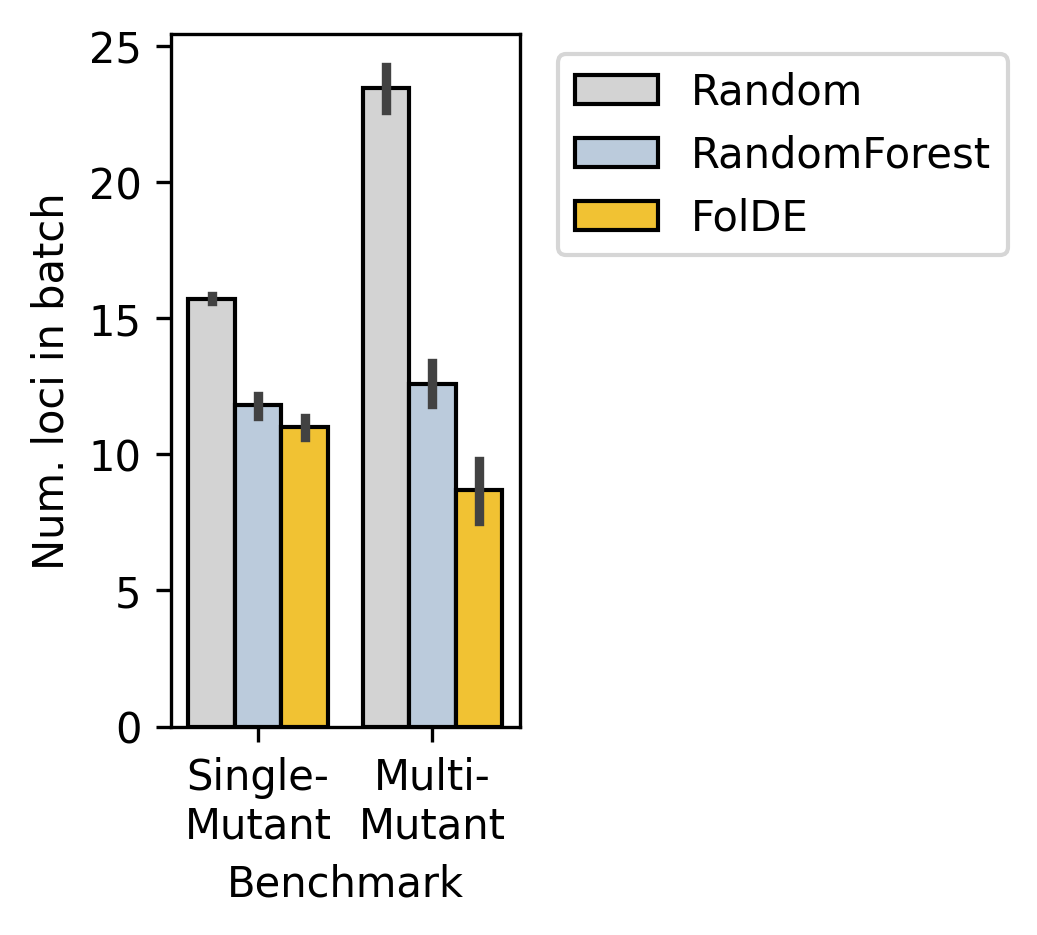

In [154]:
the_problem_df = pd.concat([
    multi_cumulative_hit_df[
        (multi_cumulative_hit_df.round_num == 2)
    ].assign(benchmark='multimutant').replace(
        {
            'FolDE-no-constantliar': 'FolDE',
            'Random': 'Random',
            'RandomToRandomForest-base': 'RandomForest',
        }
    ),
    singles_cumulative_hit_df[
        (singles_cumulative_hit_df.round_num == 2)
    ].assign(benchmark='singlemutant').replace(
        {
            'FolDE-no-constantliar': 'FolDE',
            'FolDE-random': 'Random',
            'RandomToRandomForest-base': 'RandomForest',
        }
    ),
])

# the_problem_df = the_problem_df[the_problem_df.config_name.isin(['FolDE-no-constantliar', 'RandomToRandomForest', 'Random'])]

fig, ax = plt.subplots(figsize=(1.5, 3), dpi=300)

CONFIG_NAMES = ['Random', 'RandomForest', 'FolDE']

sns.barplot(
    ax=ax,
    data=the_problem_df[the_problem_df.config_name.isin(CONFIG_NAMES)],
    x='benchmark',
    y='num_loci_this_round',
    hue='config_name',
    order=['singlemutant', 'multimutant'],
    hue_order=CONFIG_NAMES,
    # order=['Random', 'FolDE-no-constantliar']
    palette={
        'Random': 'lightgrey',
        'RandomForest': '#bbcbdc',
        'FolDE': '#F1C233',
    },
    saturation=1.0,
    edgecolor='black',
    linewidth=1.0
)
ax.set_xticklabels(['Single-\nMutant', 'Multi-\nMutant'])

ax.set_ylabel('Num. loci in batch')
ax.set_xlabel('Benchmark')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
# plt.savefig('constantliar_performance.png', dpi=300)

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_62906/585317916.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


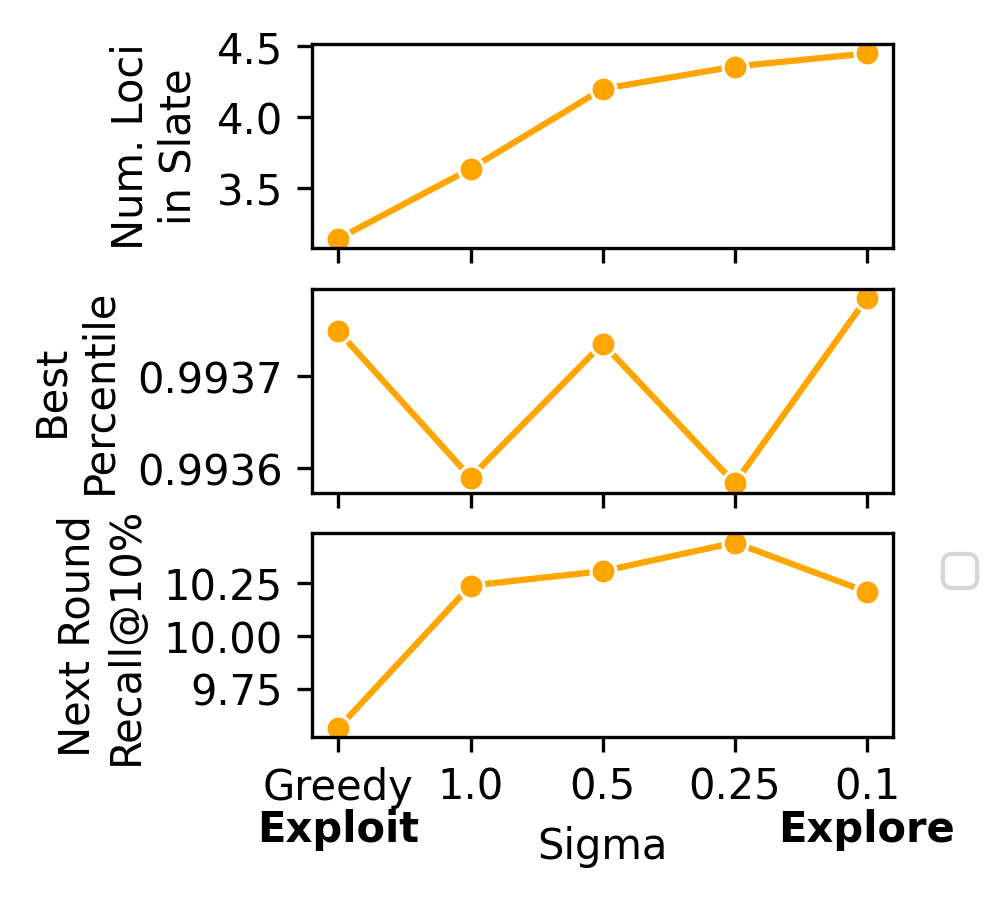

In [ ]:
NEXT_ROUND_METRIC = 'enrichment'

CTRL_COLOR = 'darkgrey'
FOLDE_COLOR = 'orange'


def config_name_to_sigma_str(config_name):
    return {
        'FolDE-clS01': '0.1',
        'FolDE-base': '0.25',
        'FolDE-clS05': '0.5',
        'FolDE-clS1': '1.0',
        'FolDE-no-constantliar': 'Greedy',
    }.get(config_name, np.nan)

def sigma_str_to_sigma(sigma_str):
    return 1000.0 if sigma_str == 'Greedy' else float(sigma_str)

the_solution_df = multimutant_diversity_df[multimutant_diversity_df.round_num == 2].groupby(['config_name']).shannon_entropy.mean().reset_index()
the_solution_df['sigma_str'] = the_solution_df.config_name.apply(config_name_to_sigma_str)
the_solution_df['sigma'] = the_solution_df.sigma_str.apply(sigma_str_to_sigma)

fig, axes = plt.subplots(3, 1, figsize=(2.5, 3), dpi=300, sharex=True)

# DO TOP PLOT
ax = axes[0]
sns.lineplot(
    ax=axes[0],
    data=the_solution_df.sort_values('sigma', ascending=False),
    x='sigma_str',
    y='shannon_entropy',
    # x_order=['1000', '2.0', '0.5', '0.25', '1.0'],
    marker='o',
    errorbar='sd',
    color=FOLDE_COLOR,
)
ax.set_ylabel('Num. Loci\nin Slate')
# ax.set_ylim(0, ax.get_ylim()[1]*1.1)


random_baseline = multimutant_diversity_df[
    (multimutant_diversity_df.round_num == 2) &
    (multimutant_diversity_df.config_name == 'Random')
].shannon_entropy.mean()
RF_baseline = multimutant_diversity_df[
    (multimutant_diversity_df.round_num == 2) &
    (multimutant_diversity_df.config_name == 'RandomToRandomForest')
].shannon_entropy.mean()
# ax.axhline(y=random_baseline, color='black', linestyle='--', label='Random')
ax.axhline(y=RF_baseline, color=CTRL_COLOR, linestyle='--', label='RandomForest')


# Middle plot.
ax = axes[1]
# Get the quality of the slate.
performance_response_df = multi_round_metrics_df[multi_round_metrics_df.round_num == 2].copy()
performance_response_df['sigma_str'] = performance_response_df.config_name.apply(config_name_to_sigma_str)

random_performance_response_baseline = performance_response_df[
    (performance_response_df.config_name == 'RandomToRandomForest')
].best_percentile_so_far.mean()

performance_response_df = performance_response_df[~performance_response_df.sigma_str.isna()]
performance_response_df['sigma'] = performance_response_df.sigma_str.apply(sigma_str_to_sigma)
performance_response_df = performance_response_df.sort_values('sigma', ascending=False)

sns.lineplot(
    ax=ax,
    data=performance_response_df,
    x='sigma_str',
    y='best_percentile_so_far',
    marker='o',
    # errorbar='sd',
    errorbar=None,
    color=FOLDE_COLOR,
)
ax.set_ylabel('Best\nPercentile')
ax.axhline(y=random_performance_response_baseline, color=CTRL_COLOR, linestyle='--', label='RandomForest')



# Bottom plot.
ax = axes[2]
# Get the next round performance (recall 1%)
next_round_performance_df = multi_round_metrics_df[multi_round_metrics_df.round_num == 3].copy()
next_round_performance_df['enrichment'] = next_round_performance_df.held_out_1pct_recall / 0.01 + next_round_performance_df.held_out_10pct_recall / 0.1
next_round_performance_df['sigma_str'] = next_round_performance_df.config_name.apply(config_name_to_sigma_str)

next_round_response_baseline = next_round_performance_df[
    (next_round_performance_df.config_name == 'RandomToRandomForest')
][NEXT_ROUND_METRIC].mean()

next_round_performance_df = next_round_performance_df[~next_round_performance_df.sigma_str.isna()]
next_round_performance_df['sigma'] = next_round_performance_df.sigma_str.apply(sigma_str_to_sigma)
next_round_performance_df = next_round_performance_df.sort_values('sigma', ascending=False)

sns.lineplot(
    ax=ax,
    data=next_round_performance_df,
    x='sigma_str',
    y=NEXT_ROUND_METRIC,
    marker='o',
    # errorbar='sd',
    errorbar=None,
    color=FOLDE_COLOR,
)
if NEXT_ROUND_METRIC == 'held_out_1pct_recall':
    ax.set_ylabel('Next Round\nRecall@1%')
else:
    ax.set_ylabel('Next Round\nRecall@10%')
# ax.axhline(y=next_round_response_baseline, color=CTRL_COLOR, linestyle='--', label='RandomForest')




# plt.savefig('constantliar.png', dpi=300, bbox_inches='tight')
# Add "Exploit" and "Explore" labels
ax = axes[2]
LABEL_DEPTH = 0.35
ax.text(0, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * LABEL_DEPTH, 
        'Exploit', ha='center', va='top', fontsize=10, fontweight='bold')
ax.text(len(ax.get_xticklabels()) - 1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * LABEL_DEPTH, 
        'Explore', ha='center', va='top', fontsize=10, fontweight='bold')
ax.set_xlabel('Sigma')
# Move legend to the right for all subplots
# for ax in axes:
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('notebooks/jacob/paperplots/fig3_constantliar_sigma_effect.svg')

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_62906/4036591411.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


[Text(0, 0, 'KCNJ2_MOUSE_Coyote-Maestas_2022_function'),
 Text(1, 0, 'CAS9_STRP1_Spencer_2017_positive'),
 Text(2, 0, 'SC6A4_HUMAN_Young_2021'),
 Text(3, 0, 'PTEN_HUMAN_Mighell_2018'),
 Text(4, 0, 'S22A1_HUMAN_Yee_2023_activity'),
 Text(5, 0, 'KKA2_KLEPN_Melnikov_2014'),
 Text(6, 0, 'PPARG_HUMAN_Majithia_2016'),
 Text(7, 0, 'MET_HUMAN_Estevam_2023'),
 Text(8, 0, 'MTHR_HUMAN_Weile_2021'),
 Text(9, 0, 'LGK_LIPST_Klesmith_2015'),
 Text(10, 0, 'AMIE_PSEAE_Wrenbeck_2017'),
 Text(11, 0, 'PAI1_HUMAN_Huttinger_2021'),
 Text(12, 0, 'A4GRB6_PSEAI_Chen_2020'),
 Text(13, 0, 'MSH2_HUMAN_Jia_2020'),
 Text(14, 0, 'MLAC_ECOLI_MacRae_2023'),
 Text(15, 0, 'RNC_ECOLI_Weeks_2023'),
 Text(16, 0, 'HMDH_HUMAN_Jiang_2019')]

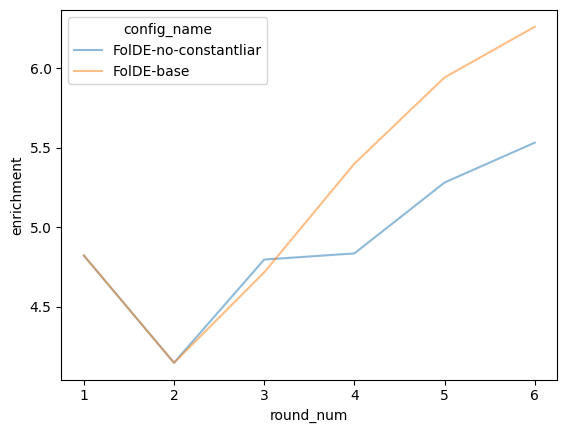

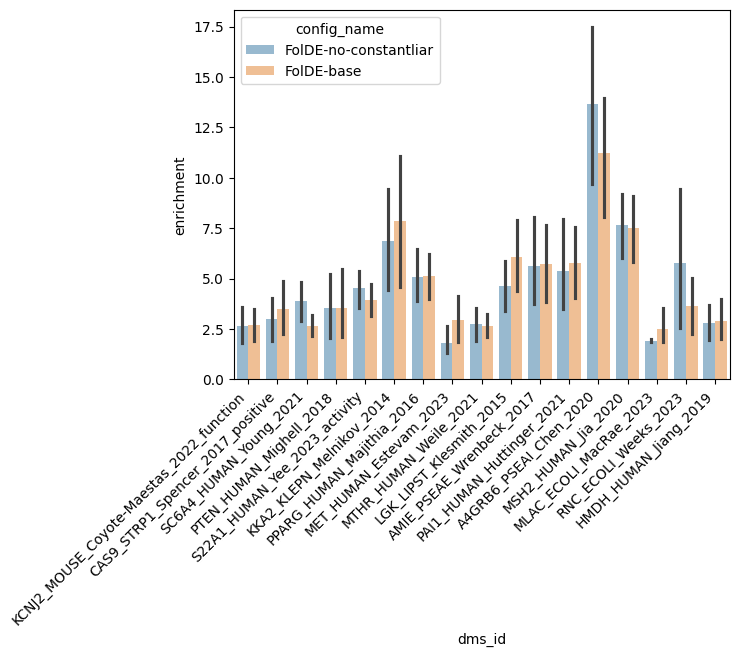

In [ ]:
singles_round_metrics_df['enrichment'] = singles_round_metrics_df.held_out_1pct_recall / 0.01 + singles_round_metrics_df.held_out_10pct_recall / 0.1
sns.lineplot(
    data=singles_round_metrics_df[singles_round_metrics_df.config_name.isin(['FolDE-base', 'FolDE-no-constantliar'])],
    x='round_num',
    y='enrichment',
    hue='config_name',
    # style='dms_id',
    legend='full',
    alpha=0.5,
    errorbar=None
)
plt.figure()
ax = sns.barplot(
    data=singles_round_metrics_df[singles_round_metrics_df.config_name.isin(['FolDE-base', 'FolDE-no-constantliar']) & (singles_round_metrics_df.round_num == 3)],
    x='dms_id',
    y='enrichment',
    hue='config_name',
    # style='dms_id',
    legend='full',
    alpha=0.5,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")